# Limpieza y cálculo estadístico
En este archivo se ejecutarán los archivos de limpieza y se definirán posibles pipelines para la preparación automática de los valores que nos pueda dar **ConnectaTel**

## Formateo de fecha en columas tipo fecha

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plans = pd.read_csv("../data/plans.csv")
users = pd.read_csv("../data/users_latam.csv")
usage = pd.read_csv("../data/usage.csv")

In [2]:
users_clean = users.copy()
usage_clean = usage.copy()

In [3]:
users.info()
display(users.sample(2))

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     4000 non-null   int64
 1   first_name  4000 non-null   str  
 2   last_name   4000 non-null   str  
 3   age         4000 non-null   int64
 4   city        3531 non-null   str  
 5   reg_date    4000 non-null   str  
 6   plan        4000 non-null   str  
 7   churn_date  466 non-null    str  
dtypes: int64(2), str(6)
memory usage: 250.1 KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
371,10371,Mateo,Garcia,76,Medellín,2022-04-12 14:04:46.271567892,Premium,NaN
3692,13692,Mateo,Garcia,19,MTY,2024-10-07 22:30:20.255063776,Basico,NaN


In [4]:
usage.info()
display(usage.sample(2))

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  str    
 3   date      39950 non-null  str    
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), str(2)
memory usage: 1.8 MB


,id,user_id,type,date,duration,length
38236,38237,13000,text,2024-06-22 00:32:00.288007200,NaN,31.0
7404,7405,11633,call,2024-02-03 12:05:40.208505212,7.53,NaN


## Revisión y estandarización de fechas
 Si el tipo de dato es string, ¿tiene caracteres raros (comas, espacios)?  → Limpiar primero → Convertir a float → Luego pd.to_datetime() con el unit correcto según cantidad de dígitos.

In [5]:
# LÓGICA DE CONVERSIÓN DE FECHA EN DATOS CON FORMATO TIMESTAMP EN STR

# Paso 1: limpiar la coma y convertir a número flotante
users_clean['churn_date'] = users_clean['churn_date'].str.replace(',', '.', regex=False)

# Paso 2: convertir a float (necesario antes de pasar a datetime)
users_clean['churn_date'] = users_clean['churn_date'].astype(float)

# Paso 3: ahora sí convertir a datetime con unit='ns'
users_clean['churn_date'] = pd.to_datetime(users_clean['churn_date'], unit='ns', errors='coerce')

# NO EJECUTAR

### Función encargada de cambiar el tipo de dato

In [6]:
def date_convert(df, date_cols):
    for col in date_cols:
        # Toma el primer valor no nulo para inspeccionar el formato
        sample = df[col].dropna().iloc[0]

        # Si parece notación científica con coma (ej: "1,7312E+18")
        if isinstance(sample, str) and 'E' in sample.upper() and ',' in sample:
            df[col] = df[col].str.replace(',', '.', regex = False)
            df[col] = df[col].astype(float)
            df[col] = pd.to_datetime(df[col], unit='ns', errors='coerce')
        else:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')
    return df

In [7]:
# Uso de función sobre dataset users
date_cols = ['reg_date', 'churn_date']
date_convert(users_clean, date_cols)
date_convert(usage_clean, ['date'])
print(users_clean.info())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   user_id     4000 non-null   int64              
 1   first_name  4000 non-null   str                
 2   last_name   4000 non-null   str                
 3   age         4000 non-null   int64              
 4   city        3531 non-null   str                
 5   reg_date    4000 non-null   datetime64[ns, UTC]
 6   plan        4000 non-null   str                
 7   churn_date  466 non-null    datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](2), int64(2), str(4)
memory usage: 250.1 KB
None


In [8]:
usage_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype              
---  ------    --------------  -----              
 0   id        40000 non-null  int64              
 1   user_id   40000 non-null  int64              
 2   type      40000 non-null  str                
 3   date      39950 non-null  datetime64[ns, UTC]
 4   duration  17924 non-null  float64            
 5   length    22104 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(2), str(1)
memory usage: 1.8 MB


### Revisión de años de registo

In [9]:
display(users_clean['reg_date'].dt.year.value_counts())
print()
print('churn_date:')
display(users_clean['churn_date'].dt.year.value_counts())

reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64


churn_date:


churn_date
2024.0    466
Name: count, dtype: int64

Tenemos 40 registros de usuarios registrados en el año 2026, el proyecto nos solicita usar datos hasta el año 2024, por lo que estos datos no podemos considerarlos información útil para el análisis, al ser un 1% es posible dejarlos núlos sin perjudicar la calidad del análisis

In [10]:
usage_clean['date'].dt.year.value_counts()

date
2024.0    39950
Name: count, dtype: int64

Todos los registros de uso de los servicios son del año 2024, por lo que el análisis del uso se reduce únicamente al año 2024

## Limpieza básica de datos

Elementos a limpiar:
- Reemplazar los sentinels de age
- Volver NaN las fechas imposibles para el análisis
- Reemplazar valores invalidos en city a NaN

### Desarrollo de Pipeline para limpieza de sentinels

In [11]:
def num_sentinels(df, num_cols):
    for col in num_cols:
    # mask indica las filas que vamos a modificar
        mask = df[col] < 0
    # sintaxis de .loc = df.loc[filas, columna]
        df.loc[mask, col] = pd.NA
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        df[f'{col}_imputed'] = mask   # flag booleano de qué se imputó

def dt_sentinels(df, dt_cols, year):
    for col in dt_cols:
        mask = df[col].dt.year > year
        df.loc[mask, col] = pd.NA

def txt_sentinels(df, txt_cols):
    for col in txt_cols:
        mask = (df[col] == '?') | (df[col].isna())
        df.loc[mask, col] = 'Desconocido'
        df[f'{col}_imputed'] = mask

In [12]:
def clean_sentinels(df, num_cols=[], dt_cols=[], txt_cols=[], year=[]):
    num_sentinels(df, num_cols)
    dt_sentinels(df, dt_cols, year)
    txt_sentinels(df, txt_cols)
    return df

In [13]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [14]:
num_cols = ['age']
dt_cols = ['reg_date']
txt_cols = ['city']
year = 2024

clean_sentinels(users_clean, num_cols, dt_cols, txt_cols, year)
users_clean.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [15]:
users_clean['reg_date'].dt.year.value_counts()

reg_date
2024.0    1330
2023.0    1316
2022.0    1314
Name: count, dtype: int64

## Revisión de valores faltantes en tabla usage

Se analizará la tabla usage para corroborar si el motivo de los valores faltantes entre *duration* y *length* son MAR o MCAR

In [16]:
display(usage_clean.sample(2))

,id,user_id,type,date,duration,length
26737,26738,10108,call,2024-04-30 23:42:38.853971348+00:00,2.28,NaN
38168,38169,11178,call,2024-06-21 17:08:54.343358582+00:00,14.94,NaN


In [17]:
usage_clean.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().mean())

,duration,length
type,,
call,0.000000,0.99933
text,0.999276,0.00000


Los valores nulos en *duration* y *length* se explican completamente por la variable *type*: registros *call* tienen *length* nulo y registros *text* tienen *duration* nulo, con una tasa superior al 99.9% en ambos casos. Esto confirma que son valores **MAR**, su ausencia depende de una variable observable del dataset y no requieren imputación ni eliminación.

## Indice estadístico de uso por usuario

Se creó una tabla agrupando los tipos de servicios para realizar el conteo de servicios realizados por cada cliente y cuánto fue la duración total o cuántos caracteres en total han utilizado los clientes.

In [18]:
usage_clean['is_text'] = (usage_clean['type'] == 'text').astype(int)
usage_clean['is_call'] = (usage_clean['type'] == 'call').astype(int)

usage_agg = usage_clean.groupby('user_id').agg({
    'is_text' : 'sum',
    'length' : 'sum',
    'is_call' : 'sum',
    'duration' : 'sum'}).reset_index()

In [19]:
usage_agg = usage_agg.rename(columns = {'is_text':'cant_mensajes', 
                                                    'length':'cant_caracteres',
                                                        'is_call' : 'cant_llamadas',
                                                        'duration':'cant_min_llamada'})
usage_agg.head()

,user_id,cant_mensajes,cant_caracteres,cant_llamadas,cant_min_llamada
0,10000,7,258.0,3,23.70
1,10001,5,226.0,10,33.18
2,10002,5,225.0,2,10.74
3,10003,11,530.0,3,8.99
4,10004,4,229.0,3,8.01


A simple vista, la cantidad de mensajes enviados por usuario es superior a la cantidad de llamadas realizadas, abriendo la probabilidad de que el servicio de mensajería sea el servicio más consumidos por los clientes.

### Combinación de tablas por usuarios

A la tabla *usage_agg* se combinará con el dataset *users* para poder identificar el origen de los clientes, rangos de edad que consume los servicios, qué tipo de plan se relaciona a estos segmentos, entre otros análisis.

In [20]:
# Unión de usage_agg con usuarios
user_profile = usage_agg.merge(users_clean, on = 'user_id', how = 'left')
user_profile.sample(3)

,user_id,cant_mensajes,cant_caracteres,cant_llamadas,cant_min_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,age_imputed,city_imputed
3597,13598,6,332.0,6,33.95,Sofia,Gomez,49.0,CDMX,2024-09-12 04:46:16.294073520+00:00,Basico,NaT,False,False
2807,12808,4,200.0,3,8.49,Mateo,Lopez,64.0,MTY,2024-02-08 21:10:23.855963992+00:00,Premium,NaT,False,False
370,10370,6,258.0,7,27.99,Mateo,Lopez,77.0,Bogotá,2022-04-12 07:30:28.357089273+00:00,Basico,NaT,False,False


In [21]:
user_profile['year'] = user_profile['reg_date'].dt.year
user_profile = user_profile[['user_id', 'first_name', 'last_name', 'age', 'city', 'plan', 'cant_mensajes', 'cant_caracteres', 'cant_llamadas', 'cant_min_llamada', 'year', 'reg_date', 'churn_date']]
user_profile.sample(3)

,user_id,first_name,last_name,age,city,plan,cant_mensajes,cant_caracteres,cant_llamadas,cant_min_llamada,year,reg_date,churn_date
3538,13539,Ana,Garcia,42.0,Cali,Basico,6,349.0,2,18.94,2024.0,2024-08-27 01:02:39.339834960+00:00,2024-08-02 00:53:20+00:00
856,10856,Carlos,Garcia,25.0,Bogotá,Basico,1,47.0,4,22.63,2022.0,2022-08-23 09:19:34.793698424+00:00,NaT
2988,12989,Mateo,Garcia,72.0,Medellín,Basico,4,165.0,1,4.62,2024.0,2024-03-29 10:38:26.376594152+00:00,NaT


In [22]:
user_profile[['age', 'cant_mensajes', 'cant_caracteres', 'cant_llamadas', 'cant_min_llamada']].describe()

,age,cant_mensajes,cant_caracteres,cant_llamadas,cant_min_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,288.128032,4.478120,23.317054
std,17.691541,2.358416,180.906841,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,184.000000,3.000000,11.120000
50%,48.000000,5.000000,268.000000,4.000000,19.780000
75%,63.000000,7.000000,361.000000,6.000000,31.415000
max,79.000000,17.000000,2028.000000,15.000000,155.690000


Las edades se podrían considerar posibles, ya que el mínimo es la mayoría de edad legal en México y Colombia (18 años) y es posible que una persona de 79 años contrate un servicio de comunicaciones.

In [23]:
user_profile['plan'].value_counts(normalize=True) *100

plan
Basico     64.866217
Premium    35.133783
Name: proportion, dtype: float64

Plan **Básico** es el servicio más contratado (64.86%) sobre el premium (35.13%)

## Visualización de distribuciones

Se analizará la distribución de las columnas relevantes con el propósito de identificar outliers en la distribución, sesgos o colas.

<Axes: xlabel='age', ylabel='Count'>

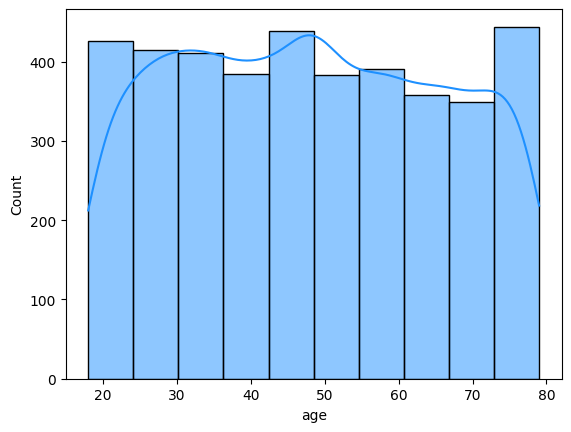

In [24]:
sns.histplot(data=user_profile, x='age', bins=10, kde=True,
             color='dodgerblue')

El *histograma* de la columna **Age** indica una concentración de usuarios entre los **30** y **50** y una *edad atípica* pero posible entre los **72** y **78** años de edad

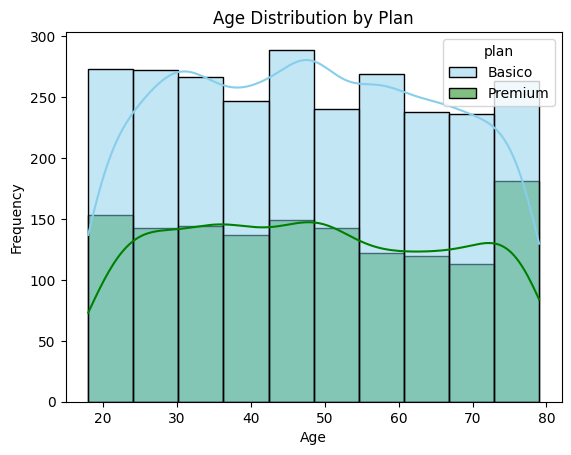

In [25]:
sns.histplot(data=user_profile, x='age', bins=10, kde=True, 
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Plan')
plt.show()

El histograma de la distribución de edad en relación con los planes que ofrece ConnectaTel indican que los clientes entre **18** y **50** años adquieren más el **plan básico**, mientras que personas el **plan premium** es contratado igual mayor mente por personas con un rango de edad entre los **18** y los **50** años, pero con una concentración entre los **72** y los **78** años.

Este comportamiento puede explicarse debido a que en México y LatAm los *ingresos promedio por hogar* **suben** hasta la franja **30–49** años, con el máximo alrededor de **40–49 años**, lo que empuja a la capacidad de cubrir varios servicios sin sacrificar necesidades; por esto muchas personas alcanzan estabilidad económica plena después de los 30 años.

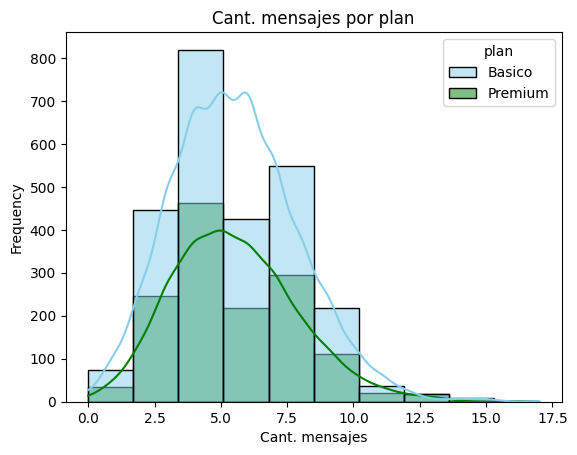

In [26]:
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, kde=True, 
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Cant. mensajes')
plt.ylabel('Frequency')
plt.title('Cant. mensajes por plan')
plt.show()

Se visualiza un sesgo hacia la derecha, concentrando la cantidad de mensajes en ambos planes hacia 5 mensajes en el plan básico con una frecuencia de 800 y en el plan premium con una frecuencia de aproximadamente 460

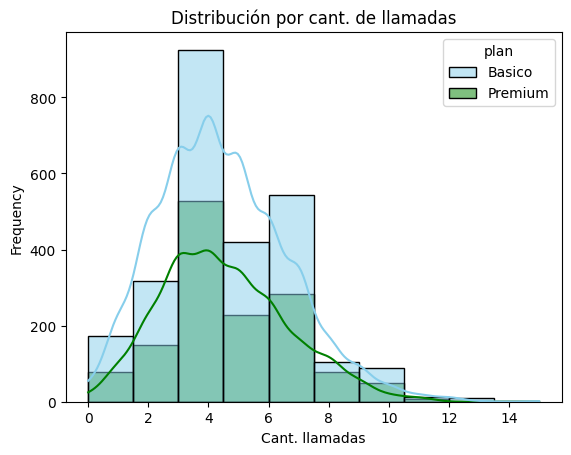

In [27]:
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, kde=True, 
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Cant. llamadas')
plt.ylabel('Frequency')
plt.title('Distribución por cant. de llamadas')
plt.show()

En ambos planes se visualiza un sesgo hacia el lado derecho del histograma, con una concentración hacia la cantidad de 4 llamadas, en el plan básico se encuentra una frecuencia de más de 800 usuarios que registraron 4 llamadas y en el plan premium suman 560 usuarios aproximadamente con 4 llamadas registradas

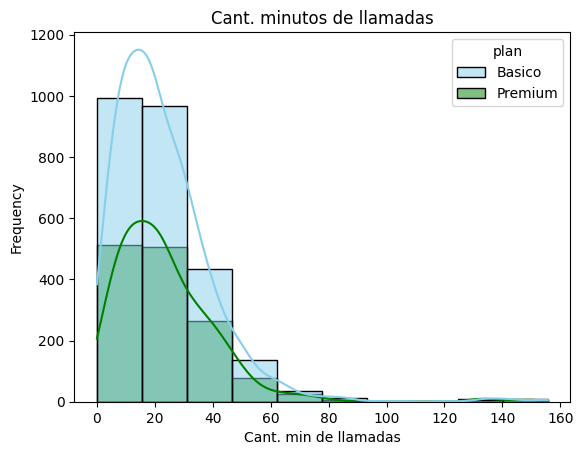

In [28]:
sns.histplot(data=user_profile, x='cant_min_llamada', bins=10, kde=True, 
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Cant. min de llamadas')
plt.ylabel('Frequency')
plt.title('Cant. minutos de llamadas')
plt.show()

La cantidad de minutos utilizadas en llamadas por usuarios muestra un sesgo bien marcado hacia la derecha, concentrando la mayor frecuencia entre 0 y 30 minutos con una frecuencia de aproximadamente 900-1000 usuarios en el plan básico y 500 en el plan premium.

Igual podemos apreciar un pequeño bulto entre 130 y 150 minutos de llamdas de usuarios con plan premium, respetando el limite de 160 minutos, siendo estos valores posibles y reales pero con muy pocos uusarios en esa cantidad de tiempo.

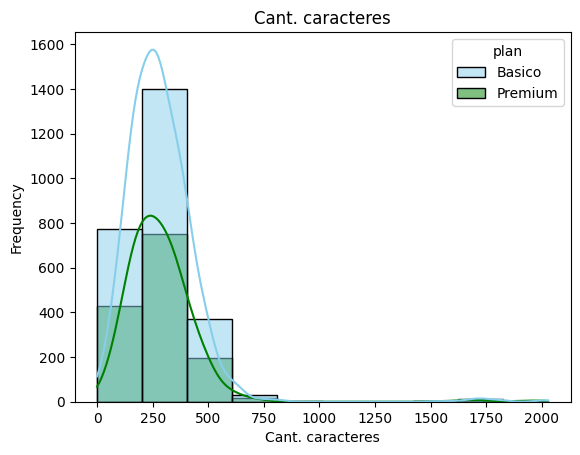

In [29]:
sns.histplot(data=user_profile, x='cant_caracteres', bins=10, kde=True, 
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Cant. caracteres')
plt.ylabel('Frequency')
plt.title('Cant. caracteres')
plt.show()

Tenemos un sesgo hacia la derecha muy pronunciada, marcando en el plan básico una frecuencia de casi 1600 caracteres utilizados por usuario, y en plan premium aproximadamente 820.

Si bien el plan premium tiene mayor cantidad de mensajes y tiempo de llamada disponible, el servicio básico muestra en los histogramas un mayor aprovechamiento de los servicios dentro de sus límites de uso mensual. Esto indica que existe la posibilidad de que al plan premium le falte algún tipo de diferenciador o beneficio contra el plan básico a demás de tener más minutos y mensajes disponibles por mes.

### Visualización de outliers con Boxplot

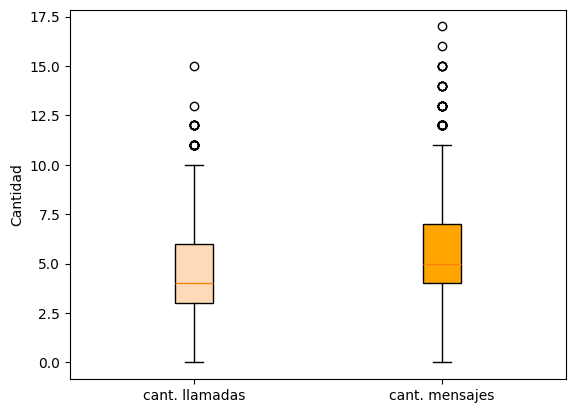

In [30]:
data = [user_profile['cant_llamadas'], user_profile['cant_mensajes']]
labels = ['cant. llamadas', 'cant. mensajes']
colors = ['peachpuff', 'orange']

fig, ax = plt.subplots()
ax.set_ylabel('Cantidad')

bplot = ax.boxplot(data,
                   patch_artist=True,  # fill with color
                   tick_labels=labels)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

Las medianas están relativamente cerca una de la otra, son rangos intercuartiles un poco pequeños, indicando que la cantidad de llamadas y mensajes se concentran en rangos pequeños, confirmando el sesgo a la derecha en los histogramas, al igual pero que los outliers a partir de la cantidad de 10 llamadas o 11 mensajes aproximadamente.
Ante un sesgo lo ideal es realizar un IQR para identificar los outliers y winsorizarlos para tener los datos al límite del rango sin eliminar registros.

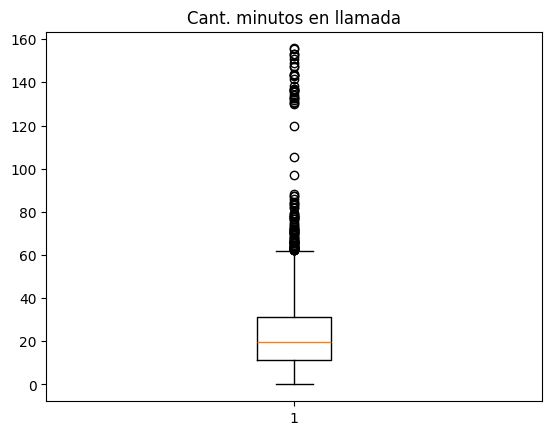

In [31]:
plt.boxplot(user_profile['cant_min_llamada'])
plt.title('Cant. minutos en llamada')
plt.show()

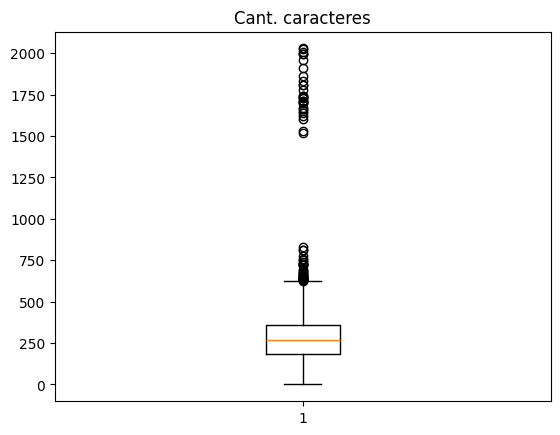

In [32]:
plt.boxplot(user_profile['cant_caracteres'])
plt.title('Cant. caracteres')
plt.show()

La cantidad de minutos en llamadas y la cantidad de caracteres tienen sus cuartiles en una posición baja con un bigote corto y un extremo superior más amplio y con demasiados outliers, confirmando así el sesgo hacia la derecha de los histograma, estos valores están dentro de los límites permitidos en los planes, sin embargo, se aprecia que varios valores dentro de esta cantidad aparecen como outliers, sería ideal realizar un IQR igual para winsorizar los valores

### Uso de IQR para identificar los límites superiores e inferiores

Al tener un alto sesgo a la derecha en los histogramas y confirmado por los boxplot, considero prudente utilizar el IQR para identificar cuáles son los límites que nos da el metodo de forma tradicional

In [33]:
def std_iqr(df,limit_cols):
    for col in limit_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        std_sup_limit = q3 + 1.5 * iqr
        std_low_limit = q1 - 1.5 * iqr
        print(f'{col}: \nIQR: {iqr} \nLower limit: {std_low_limit} \nUpper limit: {std_sup_limit}\n')

In [34]:
limit_cols = ['cant_llamadas', 'cant_min_llamada', 'cant_mensajes', 'cant_caracteres']
std_iqr(user_profile, limit_cols)

cant_llamadas: 
IQR: 3.0 
Lower limit: -1.5 
Upper limit: 10.5

cant_min_llamada: 
IQR: 20.295 
Lower limit: -19.322500000000005 
Upper limit: 61.8575

cant_mensajes: 
IQR: 3.0 
Lower limit: -0.5 
Upper limit: 11.5

cant_caracteres: 
IQR: 177.0 
Lower limit: -81.5 
Upper limit: 626.5



El IQR tradicional nos indica valores muy "cerrados" básicamente indicándonos que lo ideal sería desechar o winsorizar valores que realmente son útiles para el análisis, lo ideal sería definir percentiles límites 1% abajo y 1% arriba del total de los valores, permitiéndonos mantener la mayor cantidad de valores reales para el análisis y solo desechando los valores demasiado extremos.

In [35]:
def percentil_limit(df, limit_cols, lower_limit, up_limit):
    for col in limit_cols:
        low_limit = df[col].quantile(lower_limit)
        upper_limit = df[col].quantile(up_limit)
        print(f'{col}:')
        print(f'Límite inferior: {low_limit} \nLímite superior: {upper_limit}\n')

In [36]:
limit_cols = ['cant_llamadas', 'cant_min_llamada', 'cant_mensajes', 'cant_caracteres']
lower_limit = 0.01
up_limit = 0.99
percentil_limit(user_profile, limit_cols, lower_limit, up_limit)

cant_llamadas:
Límite inferior: 0.0 
Límite superior: 10.0

cant_min_llamada:
Límite inferior: 0.0 
Límite superior: 82.19759999999998

cant_mensajes:
Límite inferior: 1.0 
Límite superior: 12.0

cant_caracteres:
Límite inferior: 34.0 
Límite superior: 724.02



In [37]:
user_profile[limit_cols].describe()

,cant_llamadas,cant_min_llamada,cant_mensajes,cant_caracteres
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,4.478120,23.317054,5.524381,288.128032
std,2.144238,18.168095,2.358416,180.906841
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,11.120000,4.000000,184.000000
50%,4.000000,19.780000,5.000000,268.000000
75%,6.000000,31.415000,7.000000,361.000000
max,15.000000,155.690000,17.000000,2028.000000


## Winsorización de límites

In [38]:
def winsorize_limits(df, limit_cols, lower_limit, up_limit):
    for col in limit_cols:
        lower = df[col].quantile(lower_limit)
        upper = df[col].quantile(up_limit)
        df[f'limite_{col}'] = np.clip(df[col], lower, upper)
    return df

In [39]:
winsorize_limits(user_profile, limit_cols, lower_limit, up_limit)

user_profile[user_profile['cant_min_llamada'] > user_profile['cant_min_llamada'].quantile(0.99)].head(5)

,user_id,first_name,last_name,age,city,plan,cant_mensajes,cant_caracteres,cant_llamadas,cant_min_llamada,year,reg_date,churn_date,limite_cant_llamadas,limite_cant_min_llamada,limite_cant_mensajes,limite_cant_caracteres
27,10027,Ana,Gomez,28.0,MTY,Premium,8,451.0,7,84.77,2022.0,2022-01-08 09:26:03.690922730+00:00,NaT,7,82.1976,8,451.0
85,10085,Carlos,Ramirez,65.0,GDL,Basico,6,357.0,5,152.36,2022.0,2022-01-24 06:35:22.730682670+00:00,NaT,5,82.1976,6,357.0
189,10189,Mariana,Torres,63.0,MTY,Basico,9,463.0,4,155.42,2022.0,2022-02-21 18:02:25.836459115+00:00,NaT,4,82.1976,9,463.0
216,10216,Ana,Garcia,75.0,GDL,Premium,4,247.0,6,148.76,2022.0,2022-03-01 03:28:29.527381846+00:00,NaT,6,82.1976,4,247.0
226,10226,Luis,Torres,26.0,GDL,Basico,1,7.0,1,120.00,2022.0,2022-03-03 21:11:28.672168042+00:00,NaT,1,82.1976,1,34.0


In [40]:
user_profile[user_profile['cant_mensajes'] > user_profile['cant_mensajes'].quantile(0.99)].head(5)

,user_id,first_name,last_name,age,city,plan,cant_mensajes,cant_caracteres,cant_llamadas,cant_min_llamada,year,reg_date,churn_date,limite_cant_llamadas,limite_cant_min_llamada,limite_cant_mensajes,limite_cant_caracteres
315,10315,Carlos,Lopez,30.0,MTY,Basico,13,656.0,3,12.36,2022.0,2022-03-28 06:04:03.060765192+00:00,NaT,3,12.36,12,656.00
347,10347,Carlos,Garcia,77.0,Cali,Basico,13,724.0,3,21.40,2022.0,2022-04-06 00:21:36.324081021+00:00,NaT,3,21.40,12,724.00
539,10539,Sofia,Ramirez,77.0,Cali,Basico,14,777.0,5,8.66,2022.0,2022-05-28 14:06:55.903975994+00:00,NaT,5,8.66,12,724.02
908,10908,Mariana,Lopez,56.0,MTY,Basico,14,614.0,3,12.50,2022.0,2022-09-06 15:03:06.346586648+00:00,NaT,3,12.50,12,614.00
1158,11159,Mariana,Torres,79.0,Bogotá,Basico,15,740.0,2,5.15,2022.0,2022-11-14 08:32:02.880720180+00:00,NaT,2,5.15,12,724.02


In [41]:
user_profile.to_csv("../data/user_profile.csv", index=False)